# Week5 PyTorch 深度学习预测

1. **环境搭建**：配置 PyTorch 环境  
2. **模型搭建**：手写 MLP / LSTM（继承 nn.Module）  
3. **Global 训练**：多用户 electricity 数据拼接（Concat）联合训练

## 1. 环境搭建：PyTorch

In [8]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week5' else _cwd
sys.path.insert(0, os.path.join(_root, 'week5'))
from data import Electricity
from models import MLP, LSTM

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch: 2.10.0
CUDA available: False


## 2. 模型搭建：MLP 与 LSTM

In [9]:
# 超参数
D_NUM = 24      # 回看窗口（小时）
H_NUM = 1       # 预测步长
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
RANDOM_SEED = 42
MAX_USERS = 10  # 快速实验用，None 表示全部 370 用户
MAX_SAMPLES = 600  # 每用户最多样本，None 表示全部

In [10]:
# Global 模式：多用户数据拼接
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

elec = Electricity(test_ratio=0.2, max_users=MAX_USERS, max_samples_per_user=MAX_SAMPLES)
X_train, y_train, X_test, y_test = elec.get_global_slided_dataset(d_num=D_NUM, h_num=H_NUM)

print(f'用户数: {elec.n_users}')
print(f'训练集: X {X_train.shape}, y {y_train.shape}')
print(f'测试集: X {X_test.shape}, y {y_test.shape}')

用户数: 10
训练集: X (4560, 24), y (4560, 1)
测试集: X (960, 24), y (960, 1)


In [11]:
# DataLoader
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

## 3. 训练：MLP

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_mlp = MLP(input_dim=D_NUM, hidden_dims=(64, 32), output_dim=H_NUM, dropout=0.1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model_mlp.train()
    total_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = model_mlp(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.6f}')

print('MLP 训练完成')

Epoch 5/20, Loss: 0.002290
Epoch 10/20, Loss: 0.001788
Epoch 15/20, Loss: 0.001645
Epoch 20/20, Loss: 0.001421
MLP 训练完成


## 4. 训练：LSTM

In [13]:
model_lstm = LSTM(input_size=1, hidden_size=64, num_layers=2, output_dim=H_NUM, dropout=0.1).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_lstm.zero_grad()
        pred = model_lstm(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_lstm.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.6f}')

print('LSTM 训练完成')

Epoch 5/20, Loss: 0.004418
Epoch 10/20, Loss: 0.001896
Epoch 15/20, Loss: 0.001370
Epoch 20/20, Loss: 0.001239
LSTM 训练完成


## 5. 评估

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            p = model(X_b).cpu().numpy()
            preds.append(p)
            targets.append(y_b.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    return rmse, mae

rmse_mlp, mae_mlp = evaluate(model_mlp, test_loader)
rmse_lstm, mae_lstm = evaluate(model_lstm, test_loader)

print('Test Results (normalized):')
print(f'  MLP  - RMSE: {rmse_mlp:.6f}, MAE: {mae_mlp:.6f}')
print(f'  LSTM - RMSE: {rmse_lstm:.6f}, MAE: {mae_lstm:.6f}')

Test Results (normalized):
  MLP  - RMSE: 0.026652, MAE: 0.017501
  LSTM - RMSE: 0.031373, MAE: 0.021008


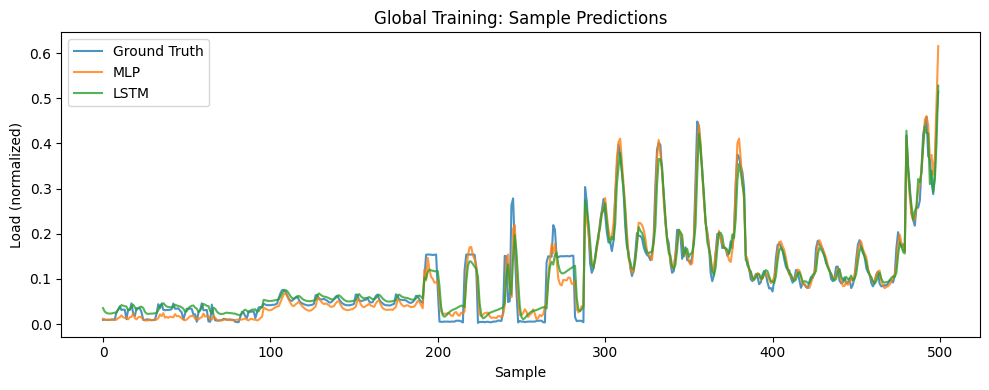

In [15]:
import matplotlib.pyplot as plt

model_mlp.eval()
model_lstm.eval()
with torch.no_grad():
    X_te = torch.from_numpy(X_test[:500]).to(device)
    p_mlp = model_mlp(X_te).cpu().numpy().flatten()
    p_lstm = model_lstm(X_te).cpu().numpy().flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test[:500].flatten(), label='Ground Truth', alpha=0.8)
ax.plot(p_mlp, label='MLP', alpha=0.8)
ax.plot(p_lstm, label='LSTM', alpha=0.8)
ax.set_xlabel('Sample')
ax.set_ylabel('Load (normalized)')
ax.legend()
ax.set_title('Global Training: Sample Predictions')
plt.tight_layout()
plt.show()